In [1]:
import pandas as pd
import numpy as np
from ml_utils.src import *
from ml_utils.config import *
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# 1.0 - Classificação do Desempenho Baseado em Fatores Socioeconômicos Usando Decision Tree

In [2]:
colunas = ['Q001','Q002','Q003', 'Q004', 'Q005', 'Q006', 'Q007', 'Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 
           'Q019', 'Q020', 'Q021', 'Q022', 'Q023', 'Q024', 'Q025', 'TP_PRESENCA_LC', 'TP_PRESENCA_CH', 'TP_PRESENCA_CN', 'TP_PRESENCA_MT', 
           'TP_FAIXA_ETARIA', 'TP_ESTADO_CIVIL', 'TP_ESCOLA', 'TP_ST_CONCLUSAO', 'IN_TREINEIRO', 
            'TP_LOCALIZACAO_ESC','TP_SIT_FUNC_ESC', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'TP_DEPENDENCIA_ADM_ESC']

df_train = pd.read_parquet(DATA_DIR, columns = colunas)
df_test = pd.read_parquet("2023", columns = colunas)

## 1.1 - Pré-Processamento dos Dados

In [3]:
df_train = preparar_dados_forests(df_train, objetivo = 'Desempenho', n_samples = 400_000)
df_test = preparar_dados_forests(df_test, objetivo = 'Desempenho', n_samples = 100_000)

## 1.2 - Construção da Matriz X e Vetor y

In [4]:
X_train = df_train.drop(columns=['MEDIA', 'FALTOU'])
y_train = df_train['MEDIA']

X_test = df_test.drop(columns=['MEDIA', 'FALTOU'])
y_test = df_test['MEDIA']

## 1.3 - Separação em Dados de Treino, Validação e Teste

In [5]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [6]:
quantil = y_train.quantile(0.5)
y_train = (y_train >= quantil).astype(int)
y_val   = (y_val   >= quantil).astype(int)
y_test  = (y_test  >= quantil).astype(int)

## 1.4 - Treinando o Modelo

In [7]:
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

print('Ein:  %0.4f' % (1 - accuracy_score(y_train, clf.predict(X_train))))
print('Eval: %0.4f' % (1 - accuracy_score(y_val,  clf.predict(X_val))))

print(classification_report(y_val, clf.predict(X_val)))

Ein:  0.0362
Eval: 0.3860
              precision    recall  f1-score   support

           0       0.61      0.63      0.62     24411
           1       0.62      0.60      0.61     24463

    accuracy                           0.61     48874
   macro avg       0.61      0.61      0.61     48874
weighted avg       0.61      0.61      0.61     48874



## 1.5 - Utilizando o algoritmo de Minimal Cost-Complexity

C:\Users\Micael\AppData\Local\Temp\ipykernel_13212\306740880.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


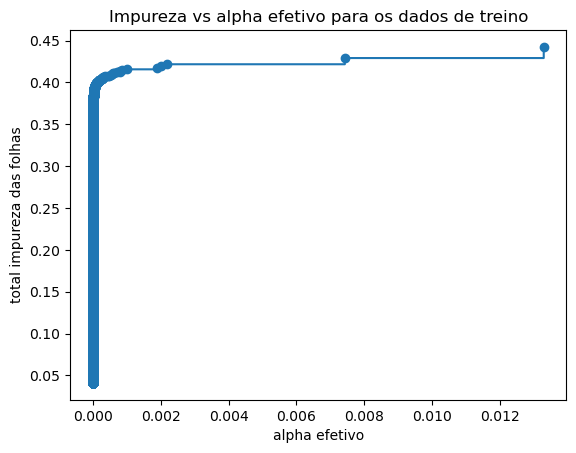

In [8]:
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("alpha efetivo")
ax.set_ylabel("total impureza das folhas")
ax.set_title("Impureza vs alpha efetivo para os dados de treino")
fig.show()

## 1.7 - Regularizar o alpha com Minimal Cost-Complexity via cross-validation

In [10]:
alphas_reduzidos = np.unique(np.quantile(path.ccp_alphas, np.linspace(0, 1, 200)))

param_grid = {
    'ccp_alpha': alphas_reduzidos,
    'class_weight':[None,'balanced'],
    'max_depth': [3, 5, 10, 15],
}

CV_clf = GridSearchCV(estimator=clf, param_grid=param_grid, cv = 5, verbose=2, n_jobs=1)

CV_clf.fit(X_train, y_train)

print('Ein: %0.4f' % (1 - accuracy_score(y_train, CV_clf.predict(X_train))))
print('Eval: %0.4f' % (1 - accuracy_score(y_val, CV_clf.predict(X_val))))

print(classification_report(y_val, CV_clf.predict(X_val)))

Fitting 5 folds for each of 1280 candidates, totalling 6400 fits
[CV] END ccp_alpha=-6.776263578034403e-21, class_weight=None, max_depth=3; total time=   0.0s
[CV] END ccp_alpha=-6.776263578034403e-21, class_weight=None, max_depth=3; total time=   0.0s
[CV] END ccp_alpha=-6.776263578034403e-21, class_weight=None, max_depth=3; total time=   0.0s
[CV] END ccp_alpha=-6.776263578034403e-21, class_weight=None, max_depth=3; total time=   0.0s
[CV] END ccp_alpha=-6.776263578034403e-21, class_weight=None, max_depth=3; total time=   0.0s
[CV] END ccp_alpha=-6.776263578034403e-21, class_weight=None, max_depth=5; total time=   0.0s
[CV] END ccp_alpha=-6.776263578034403e-21, class_weight=None, max_depth=5; total time=   0.0s
[CV] END ccp_alpha=-6.776263578034403e-21, class_weight=None, max_depth=5; total time=   0.0s
[CV] END ccp_alpha=-6.776263578034403e-21, class_weight=None, max_depth=5; total time=   0.0s
[CV] END ccp_alpha=-6.776263578034403e-21, class_weight=None, max_depth=5; total time=   

d:\anaconda\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
40 fits failed out of a total of 6400.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
40 fits failed with the following error:
Traceback (most recent call last):
  File "d:\anaconda\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\anaconda\Lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "d:\anaconda\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "d:\anaconda\Lib\site-packages\sklearn\utils\_param_validation.py", line 95, in validate_param

Ein: 0.2954
Eval: 0.3058
              precision    recall  f1-score   support

           0       0.69      0.72      0.70     24411
           1       0.70      0.67      0.69     24463

    accuracy                           0.69     48874
   macro avg       0.69      0.69      0.69     48874
weighted avg       0.69      0.69      0.69     48874



In [11]:
CV_clf.best_params_

{'ccp_alpha': 2.3819053342674275e-05, 'class_weight': None, 'max_depth': 15}

## Treinando o modelo com todos os dados

In [13]:
clf = DecisionTreeClassifier(**CV_clf.best_params_)
clf.fit(X_train, y_train)

print('Ein: %0.4f' % (1 - accuracy_score(y_train, CV_clf.predict(X_train))))
print('Eout: %0.4f' % (1 - accuracy_score(y_test, CV_clf.predict(X_test))))

print(classification_report(y_test, clf.predict(X_test)))

Ein: 0.2954
Eout: 0.3199
              precision    recall  f1-score   support

           0       0.64      0.61      0.63     29965
           1       0.71      0.74      0.72     38114

    accuracy                           0.68     68079
   macro avg       0.67      0.67      0.67     68079
weighted avg       0.68      0.68      0.68     68079



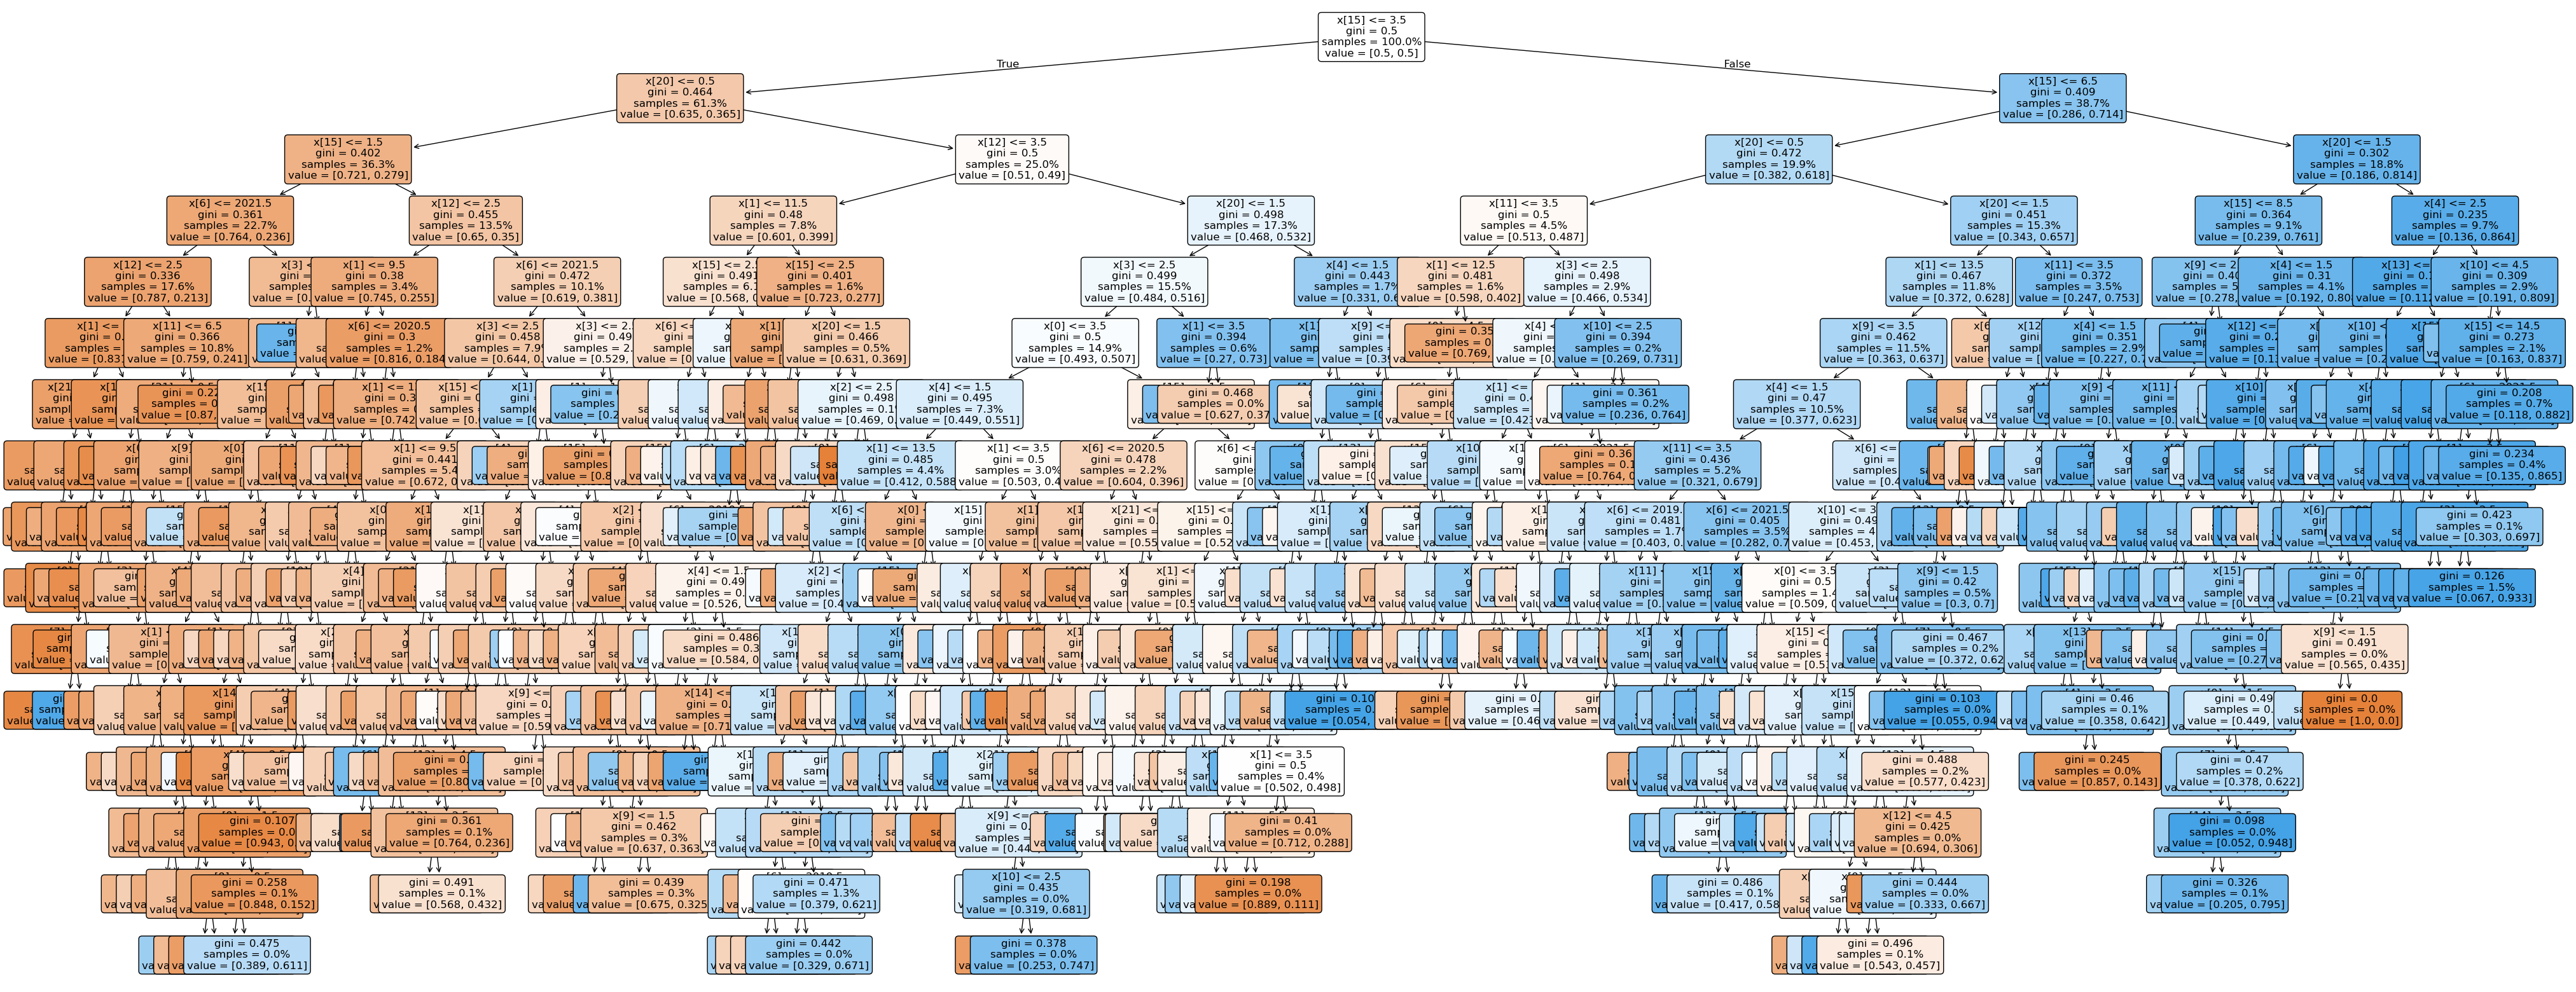

In [14]:
plt.figure(figsize=(50,20))

plot_tree(
    clf,
    filled=True,
    proportion=True,
    fontsize=12,
    rounded=True
)

plt.show()

In [7]:
clf = DecisionTreeClassifier(ccp_alpha = 2.3819053342674275e-05, class_weight= None, max_depth= 15)
clf.fit(X_train, y_train)

print('Ein: %0.4f' % (1 - accuracy_score(y_train, clf.predict(X_train))))
print('Eout: %0.4f' % (1 - accuracy_score(y_test, clf.predict(X_test))))

print(classification_report(y_test, clf.predict(X_test)))

joblib.dump(clf, 'dt_desempenho.joblib')

Ein: 0.2969
Eout: 0.3202
              precision    recall  f1-score   support

           0       0.61      0.75      0.67     29965
           1       0.76      0.63      0.69     38114

    accuracy                           0.68     68079
   macro avg       0.69      0.69      0.68     68079
weighted avg       0.69      0.68      0.68     68079



['dt_desempenho.joblib']